<a href="https://colab.research.google.com/github/ruizfranco02/Proyecto-Final_DATA-SCIENCE-I/blob/main/ProyectoParteIII-Ruiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Datos Estadísticos de LPF 2015-2022

## ***Alumno: Franco Gabriel Ruiz.***

En este notebook presentamos el Proyecto Final aplicando la teoría y práctica de las clases con técnicas de selección de características, regresión y evaluación de métricas para profundizar las siguientes hipotesis:
1. ¿Los equipos locales marcan más goles que los visitantes?
2. ¿El valor del mercado tiene relación con los goles anotados?
3. ¿Influyen las variables físicas en el rendimiento del equipo (promedio de goles por partidos)?


In [20]:
# Librerias necesarias para reproducir el notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
%matplotlib inline


In [12]:
# Carga de dataset.
url = "https://raw.githubusercontent.com/ruizfranco02/Proyecto-Final_DATA-SCIENCE-I/refs/heads/main/Dataset/afa_2015_2022_spa.csv"  # Asegúrate de que esté en la misma carpeta
df = pd.read_csv(url)
print('Muestreo:', df.shape)
df.head()

Muestreo: (2821, 34)


,torneo,fecha,partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local,tiros_arco_local,intentos_local,...,proporcion_zurdos_local,valor_mercado_visitante,altura_media_visitante,edad_media_visitante,proporcion_zurdos_visitante,resultado,fecha_encuentro,apuesta_local,apuesta_visitante,apuesta_empate
0,Campeonato 2015,1,1,Velez,Aldosivi,2,0,NaN,NaN,NaN,...,0.301887,8.725,1.790370,28.100000,0.233333,L,2015-02-13 18:00:00,1.75,5.01,3.37
1,Campeonato 2015,1,2,Racing Club,Rosario Central,0,1,NaN,NaN,NaN,...,0.297297,18.350,1.789333,25.608696,0.217391,V,2015-02-13 21:10:00,1.80,4.82,3.23
2,Campeonato 2015,1,3,San Lorenzo,Colon,2,0,NaN,NaN,NaN,...,0.285714,12.125,1.801026,24.948718,0.282051,L,2015-02-14 17:00:00,1.70,5.55,3.34
3,Campeonato 2015,1,4,Gimnasia (LP),Def y Justicia,0,1,NaN,NaN,NaN,...,0.227273,12.050,1.776889,25.460000,0.240000,V,2015-02-14 17:00:00,2.06,3.82,3.09
4,Campeonato 2015,1,5,Godoy Cruz,San Martin (SJ),1,1,NaN,NaN,NaN,...,0.226415,11.250,1.780000,26.153846,0.205128,E,2015-02-14 19:15:00,2.03,3.82,3.15


In [13]:
from threading import local
# Detección automática de columnas relevantes

def find_col(df, keywords):
    for k in keywords:
        for c in df.columns:
            if k.lower() in c.lower():
                return c
    return None

local_col = find_col(df, ['goles_local','goles_locales'])
visitante_col = find_col(df, ['goles_visitante','goles_visitantes'])
equipo_local_col = find_col(df, ['equipo_local','local',])
equipo_visitante_col = find_col(df, ['equipo_visitante','visitante'])

print('Detectadas:')
print('goles local ->', local_col)
print('goles_visitante ->', visitante_col)
print('equipo local->', equipo_local_col)
print('equipo visitante ->', equipo_visitante_col)


Detectadas:
goles local -> goles_local
goles_visitante -> goles_visitante
equipo local-> equipo_local
equipo visitante -> equipo_visitante


## Hipótesis 1: ¿Los equipos locales marcan más goles que los visitantes?

Realizamos una comparación de medias de goles dejandolo expresado en un gráfico para que el resultado sea visible.

Media goles local: 1.292449485997873
Media goles visitante: 0.9907834101382489


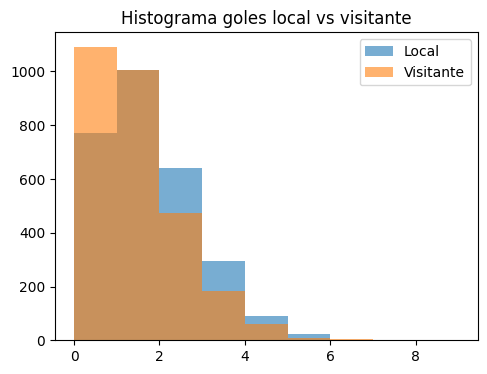

In [14]:
# Hipótesis 1: comparación local vs visitante
if local_col and visitante_col:
    local = df[local_col].astype(float).dropna()
    visitante = df[visitante_col].astype(float).dropna()
    paired = df[[local_col, visitante_col]].dropna()
    mean_local = local.mean(); mean_visitante = visitante.mean()
    tstat, pval = stats.ttest_rel(paired[local_col].astype(float), paired[visitante_col].astype(float))
    print('Media goles local:', mean_local)
    print('Media goles visitante:', mean_visitante)

    # Gráfico
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(local, bins=range(0, int(max(local.max(), visitante.max())+2)), alpha=0.6)
    plt.hist(visitante, bins=range(0, int(max(local.max(), visitante.max())+2)), alpha=0.6)
    plt.legend(['Local','Visitante'])
    plt.title('Histograma goles local vs visitante')


## Hipótesis 2: ¿El valor de mercado tiene relación con los goles anotados?

Analizamos el valor de marcado de cada uno de los equipos y lo comparamos en un grafico con la cantidad de goles que tienen.

Columnas de valor de mercado detectadas: valor_mercado_local valor_mercado_visitante valor_mercado_local
Correlación vm_local vs goles locales: r=0.1350868604651708, p=5.815179836168391e-13, n=2821


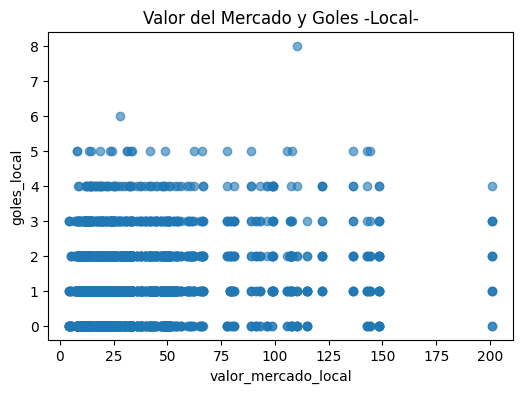

Correlación vm_visitante vs goles_visitante: r=0.16263815400798082, p=3.551182930952118e-18, n=2821


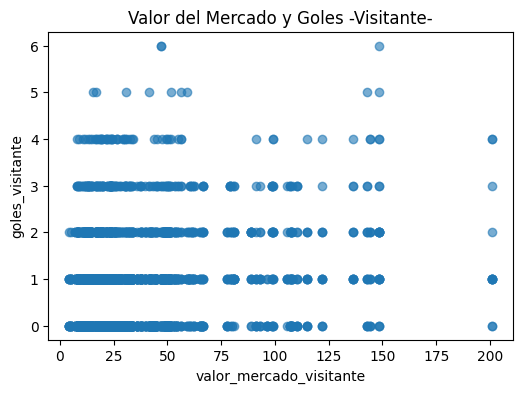

In [15]:
# Detectar columnas de valor de mercado
vm_local = find_col(df, ['valor_mercado_local','valor_local'])
vm_visitante = find_col(df, ['valor_mercado_visitante','valor_visitante'])
vm_general = find_col(df, ['valor_mercado','valor_equipo'])
print('Columnas de valor de mercado detectadas:', vm_local, vm_visitante, vm_general)

# Intentar correlación con goles locales y visitantes
if vm_local and local_col:
    x = df[vm_local]
    y = df[local_col].astype(float)
    mask = x.notna() & y.notna()
    if mask.sum() > 5:
        r, p = stats.pearsonr(x[mask], y[mask])
        print('Correlación vm_local vs goles locales: r={}, p={}, n={}'.format(r, p, mask.sum()))
        plt.figure(figsize=(6,4))
        plt.scatter(x[mask], y[mask], alpha=0.6)
        plt.xlabel(vm_local); plt.ylabel(local_col)
        plt.title('Valor del Mercado y Goles -Local-')
        plt.show()

if vm_visitante and visitante_col:
    x = df[vm_visitante]
    y = df[visitante_col].astype(float)
    mask = x.notna() & y.notna()
    if mask.sum() > 5:
        r, p = stats.pearsonr(x[mask], y[mask])
        print('Correlación vm_visitante vs goles_visitante: r={}, p={}, n={}'.format(r, p, mask.sum()))
        plt.figure(figsize=(6,4))
        plt.scatter(x[mask], y[mask], alpha=0.6)
        plt.xlabel(vm_visitante); plt.ylabel(visitante_col)
        plt.title('Valor del Mercado y Goles -Visitante-')
        plt.show()


## Hipótesis 3: ¿Influyen las variables físicas en el rendimiento?

Analizamos los promedios de los goles, edad y altura y realizamos graficos donde refejado las características de los equipos.

In [16]:
# Construcción de tabla por equipo con promedio de goles por partido
def build_team_table(df, local_col, visitante_col, equipo_local_col, equipo_visitante_col):
    df_partidos = df[[equipo_local_col, equipo_visitante_col, local_col, visitante_col]].dropna()
    goles_local = df_partidos[[equipo_local_col, local_col]].rename(columns={equipo_local_col:'equipo', local_col:'goles'})
    goles_visitante = df_partidos[[equipo_visitante_col, visitante_col]].rename(columns={equipo_visitante_col:'equipo', visitante_col:'goles'})
    goles_totales = pd.concat([goles_local, goles_visitante], ignore_index=True)
    goles= goles_totales.groupby('equipo').sum().rename(columns={'goles':'goles_totales'})

    #Partidos
    partidos_local = df_partidos[[equipo_local_col]].rename(columns={equipo_local_col:'equipo'})
    partidos_visitante = df_partidos[[equipo_visitante_col]].rename(columns={equipo_visitante_col:'equipo'})
    partidos_totales = pd.concat([partidos_local, partidos_visitante], ignore_index=True)
    partidos = partidos_totales.groupby('equipo').size().rename('partidos')
    estadistica_equipo = goles.join(partidos).reset_index()
    estadistica_equipo['promedio_goles'] = estadistica_equipo['goles_totales'] / estadistica_equipo['partidos']
    return estadistica_equipo

equipo_df = build_team_table(df, local_col, visitante_col, equipo_local_col, equipo_visitante_col)
print('Proporciones de la Tabla', equipo_df.shape)
equipo_df.head()


Proporciones de la Tabla (38, 4)


,equipo,goles_totales,partidos,promedio_goles
0,Aldosivi,157,176,0.892045
1,Argentinos,170,172,0.988372
2,Arsenal,169,178,0.949438
3,Atl Rafaela,74,76,0.973684
4,Atl Tucuman,201,173,1.161850


Equipo goles y variables fisicas:


/tmp/ipython-input-1832264665.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


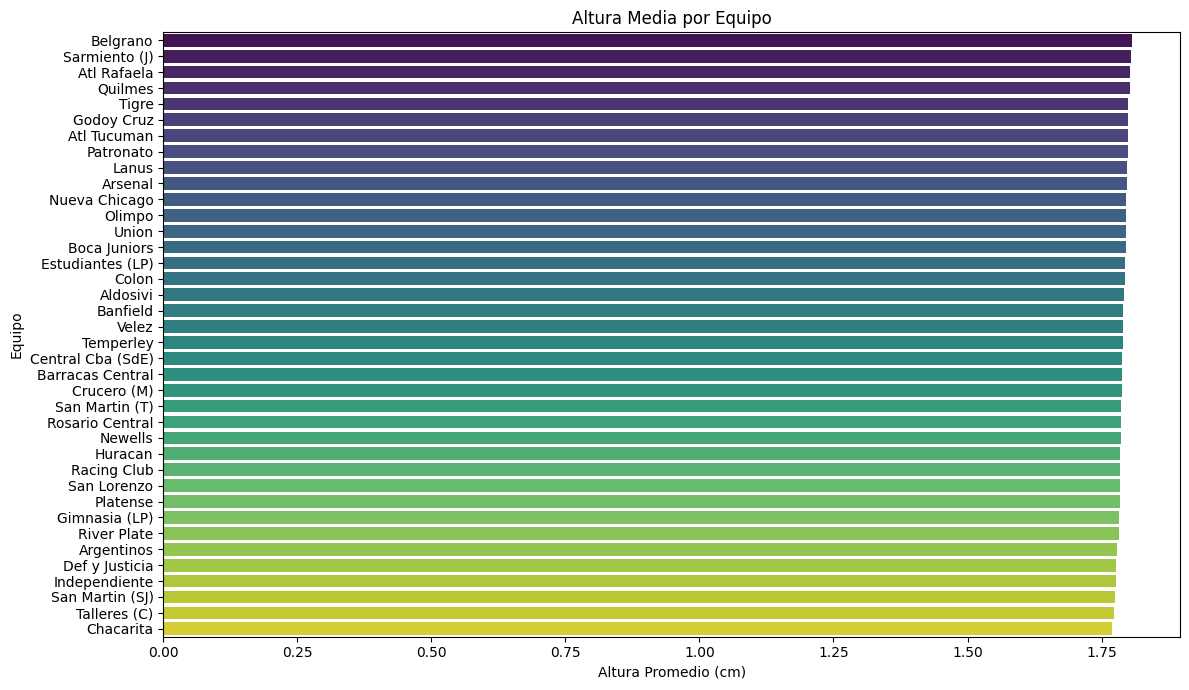

/tmp/ipython-input-1832264665.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


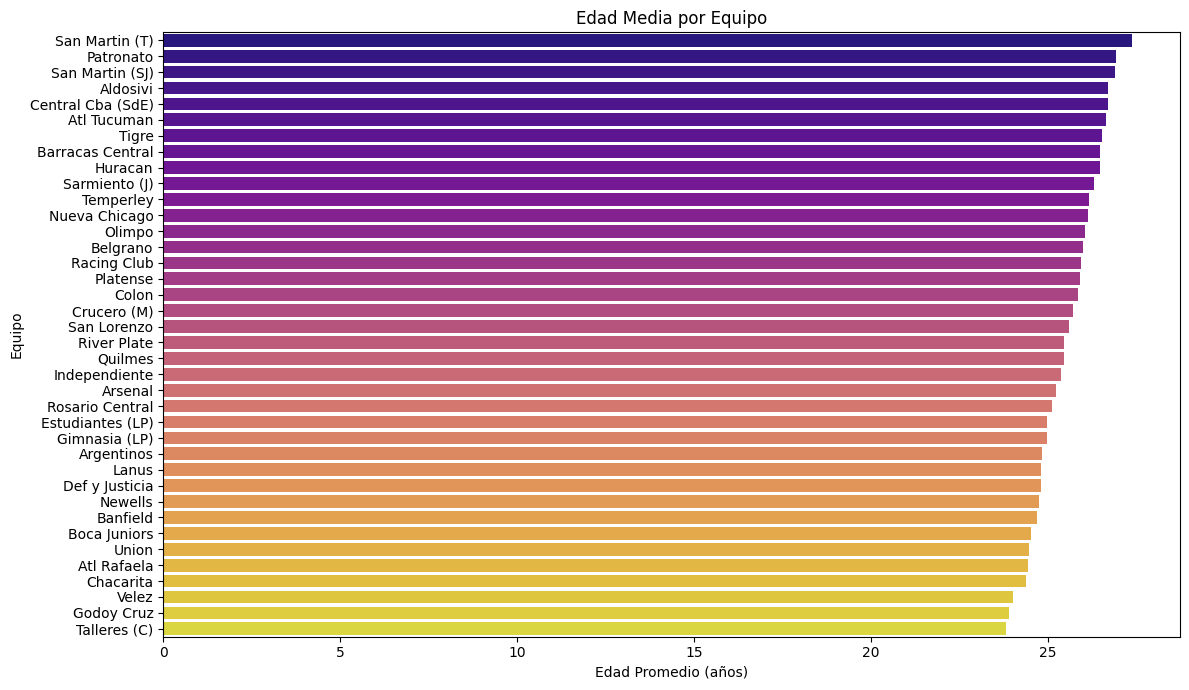

In [17]:
# Buscamos variables fisicas de ambos equipos y las promediamos

# Buscamos los equipos
equipo_df = build_team_table(df, local_col, visitante_col, equipo_local_col, equipo_visitante_col)

# Definimos las variables fisicas a promediar
variables_fisicas_promedio = ['altura_media', 'edad_media']

equipo_vf = pd.DataFrame(index=equipo_df['equipo'].unique()).rename_axis('equipo')

for variables_fisicas in variables_fisicas_promedio:
    local_col_nombre = find_col(df, [f'{variables_fisicas}_local', variables_fisicas])
    visitante_col_nombre = find_col(df, [f'{variables_fisicas}_visitante', variables_fisicas])

    series_for_concat = []
    if local_col_nombre:
        local_data = df.loc[df[equipo_local_col].notna() & df[local_col_nombre].notna(), [equipo_local_col, local_col_nombre]]
        mean_series_local = local_data.groupby(equipo_local_col)[local_col_nombre].mean().rename(f'{variables_fisicas}_local')
        series_for_concat.append(mean_series_local)

    if visitante_col_nombre:
        visitante_data = df.loc[df[equipo_visitante_col].notna() & df[visitante_col_nombre].notna(), [equipo_visitante_col, visitante_col_nombre]]
        mean_series_visitante = visitante_data.groupby(equipo_visitante_col)[visitante_col_nombre].mean().rename(f'{variables_fisicas}_visitante')
        series_for_concat.append(mean_series_visitante)

    if series_for_concat:
        if len(series_for_concat) == 2:
            # Concatenamos las variables y las promediamos
            combined_df_for_pk = pd.concat(series_for_concat, axis=1)
            equipo_vf[f'promedio_{variables_fisicas}'] = combined_df_for_pk.mean(axis=1)
        elif len(series_for_concat) == 1:
            equipo_vf[f'promedio_{variables_fisicas}'] = series_for_concat[0]

# Tabla de equipos con sus promedio de goles y variables fisicas
equipo_df = equipo_df.set_index('equipo').join(equipo_vf)
equipo_df = equipo_df.reset_index()
print('Equipo goles y variables fisicas:')
equipo_df.head()


# Gráfico: Ranking de Altura por Equipo
plt.figure(figsize=(12, 7))
sns.barplot(
    # Ordenamos los valores
    data=equipo_df.sort_values('promedio_altura_media', ascending=False),
    x='promedio_altura_media',
    y='equipo',
    palette='viridis'
)
plt.title('Altura Media por Equipo')
plt.xlabel('Altura Promedio (cm)')
plt.ylabel('Equipo')
plt.tight_layout()
plt.show()

# Gráfico: Ranking de Edad por Equipo
plt.figure(figsize=(12, 7))
sns.barplot(
    data=equipo_df.sort_values('promedio_edad_media', ascending=False),
    x='promedio_edad_media',
    y='equipo',
    palette='plasma'
)
plt.title('Edad Media por Equipo')
plt.xlabel('Edad Promedio (años)')
plt.ylabel('Equipo')
plt.tight_layout()
plt.show()

## -Modelo de regresión.

Realizamos una predicción sobre el promedio de los goles utilizando las variables de la hipotesis 3 para lograr este gráfico.

In [32]:
# Definimos el target a predecir.
y = equipo_df['promedio_goles']

# Elegimos las variables que acompañan el target.
variables_cols = [
    col for col in ['goles_local', 'goles_visitante', 'promedio_goles', 'variables_fisicas_promedio']
    if col in equipo_df.columns]
X = equipo_df[variables_cols]

# Realizamos Feature Selection
k = 5
selector = SelectKBest(f_regression, k=min(k, X.shape[1]))
selector.fit(X.fillna(X.mean()), y)
selected_features = X.columns[selector.get_support()]
X_selected = X[selected_features]

# Modelo de regresión.
Xs = StandardScaler().fit_transform(X_selected.fillna(X_selected.mean()))
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

##-Cálculo de métricas básicas.
Para validar el modelo de regresión con los datos que buscamos calculamos las siguientes métricas:

-MSE = error cuadrático medio

-RMSE = raíz del error cuadrático medio

-MAE = error absoluto medio

-R² = coeficiente de determinación

In [31]:
#Cálculo de métricas
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
print('RMSE:', rmse,
      'R2:', r2,
      "MAE:", mae,
      "MSE:", mse
      )

RMSE: 0.07449192464121923 R2: 0.8439921737905312 MAE: 0.035884766624477205 MSE: 0.0055490468367530845


##-Gráfico Predicción vs Real
Luego del buscar un entrenamieto del modelo y validarlo conlas métricas así quedaria el gráfico donde se demuestra el entrenamiento que sufrió el modelo.

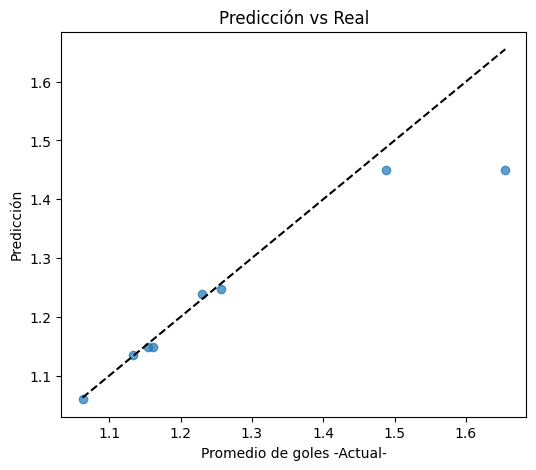

In [33]:
# Gráfico
plt.figure(figsize=(6,5))
plt.scatter(y_test, preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Promedio de goles -Actual-'); plt.ylabel('Predicción')
plt.title('Predicción vs Real')
plt.show()

## -Conclusiones

Según los resultados obtenidos podemos llegar a la conclusión que:
- Hipótesis 1: Los equipos locales marcan mas que los visitantes, por lo que podríamos decir que jugar en condición de local es una ventaja.
- Hipótesis 2: El valor del mercado deja en evidencia que el jugador tiene más rendimiento pero no quiere decir que un jugador de poco valor haga la diferencia, por lo que el valor es simplemente cuestión de rendimiento que aumenta sgún las características propias del jugador.
- Hipótesis 3: Las variables físicas del jugador no son tan determinantes en los goles, no en cuanto un jugador específico si puede hacer la diferencia si la mayoría del plantel es jóven se va a notar en su rendimiento.

El modelo **Random Forest Regressor** se comportó de forma adecuada para predecir la variable objetivo seleccionada.  
Los resultados muestran un **R² alto** y valores de **MSE, MAE y RMSE bajos**, lo cual indica un buen ajuste del modelo como se puede ver en el gráfico aportado.

